# ADC Synchronous Testing Report

## Methods

Buffered differential ADC measurements were performed using the firmware in main.c, where BUTTON1 triggered acquisition of a 10 Hz sinusoidal signal across AIN1 and AIN2. The ADC was configured to collect a full buffer in a single adc_read() call using extra_samplings. For nominal testing, the sampling interval was set to 5000 us (200 Hz), with the buffer sized to capture approximately 20 cycles. The ADC buffer was logged as a hexadecimal array and the signal frequency was computed in firmware using a zero-crossing method.

The hexadecimal data were decoded in a Jupyter notebook and compared with oscilloscope CSV data of the input signal. Three runs were collected for each sampling condition. The sampled signals were plotted alongside the input waveform, and frequencies were estimated for each run. Mean values and 95% confidence intervals were computed from the replicates. For the 200 Hz case, where all runs were identical, uncertainty was instead based on the measurement resolution and reported as ±0.25 Hz. The procedure was repeated at a reduced sampling frequency of 5 Hz to evaluate aliasing.

## Results

### Scope vs. ADC Hex Data


200 Hz Sampling
---------------
Run 1: estimated sampled frequency = 10.00 Hz


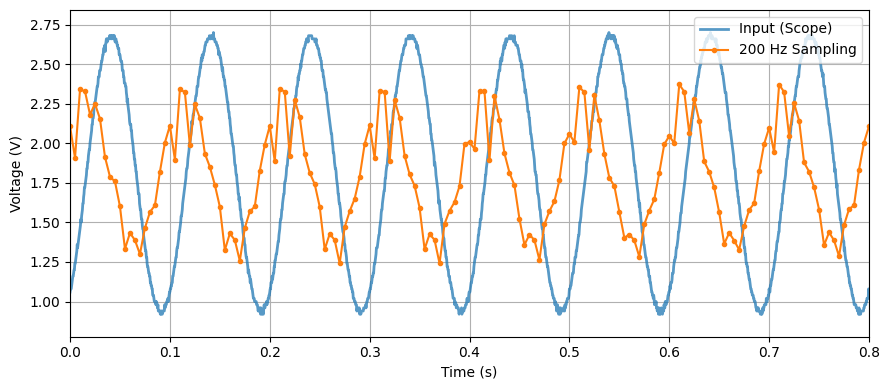

Run 2: estimated sampled frequency = 10.00 Hz


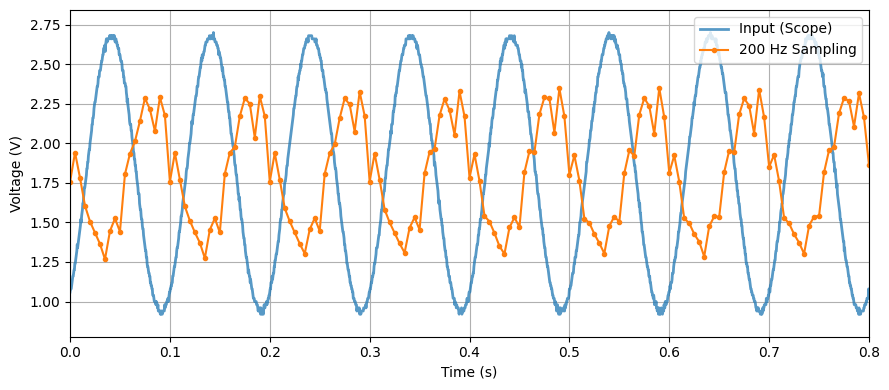

Run 3: estimated sampled frequency = 10.00 Hz


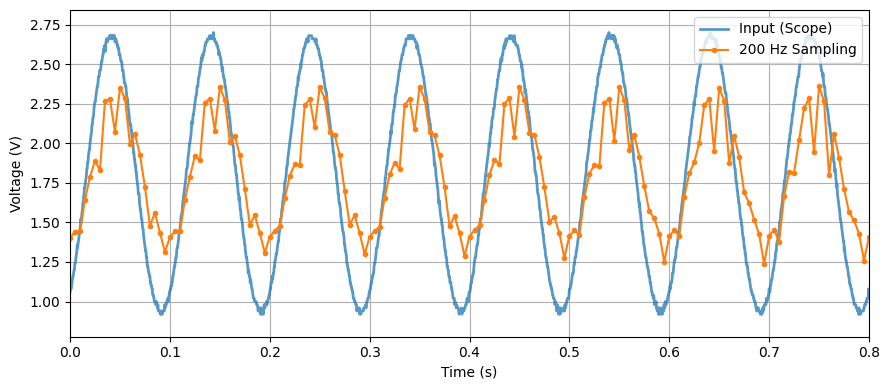


5 Hz Sampling
-------------
Run 1: estimated sampled frequency = 0.50 Hz


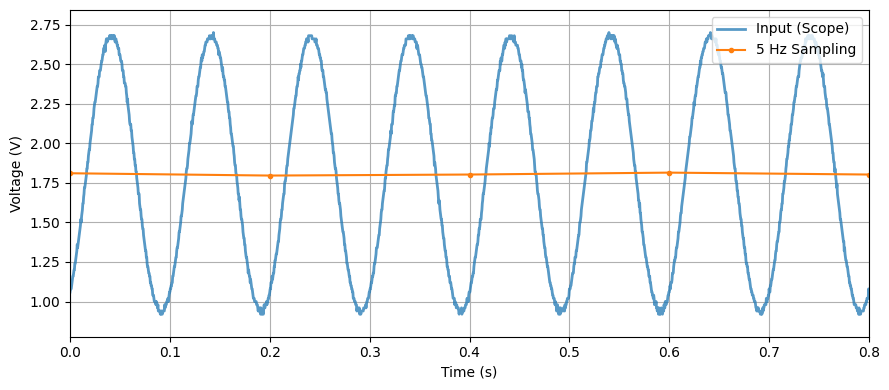

Run 2: estimated sampled frequency = 0.50 Hz


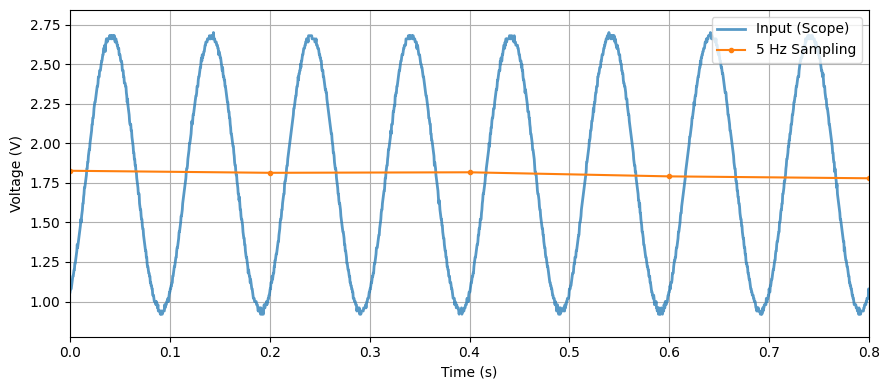

Run 3: estimated sampled frequency = 2.50 Hz


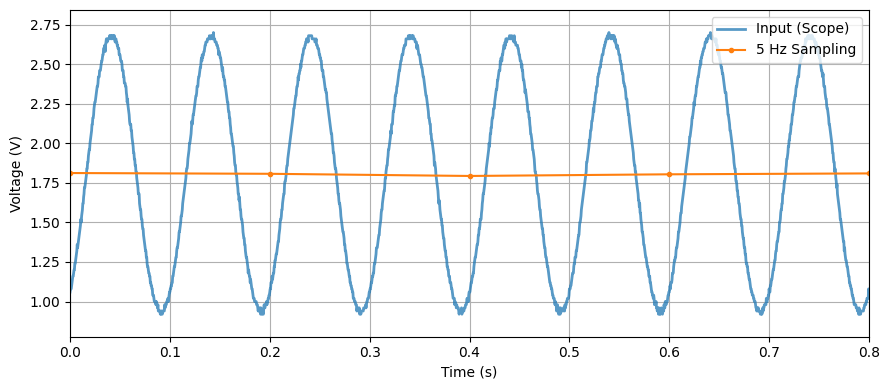

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bme554 import read_hex_data, unwrap_twos_complement

SAMPLES_NOMINAL = 400
SAMPLES_ALIAS = 10
VREF = 3.3
RESOLUTION = 4096

NOMINAL_FS = 200.0   # Hz
ALIASED_FS = 5.0     # Hz

SCOPE_FILE = "scope.csv"
NOMINAL_FILE = "adc_nominal.txt"
ALIASED_FILE = "adc_alias.txt"

TMAX_PLOT = 0.8

def estimate_freq_fft(signal, fs):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)
    idx = np.argmax(np.abs(fft_vals[1:])) + 1
    return fft_freqs[idx]

def split_hex_runs(filename, samples_per_run):
    hex_data = read_hex_data(filename)
    bytes_per_run = 2 * samples_per_run
    runs = []
    for i in range(0, len(hex_data), bytes_per_run):
        chunk = hex_data[i:i + bytes_per_run]
        if len(chunk) == bytes_per_run:
            runs.append(chunk)
    return runs

def decode_run(run_chunk, vref, resolution):
    adc_vals = np.array(unwrap_twos_complement(run_chunk), dtype=float)
    return (adc_vals / resolution) * vref

def load_scope_csv(scope_file):
    scope_df = pd.read_csv(scope_file, header=None)
    t_scope = pd.to_numeric(scope_df.iloc[:, 3], errors="coerce")
    v_scope = pd.to_numeric(scope_df.iloc[:, 4], errors="coerce")
    valid = t_scope.notna() & v_scope.notna()
    t_scope = t_scope[valid].to_numpy(dtype=float)
    v_scope = v_scope[valid].to_numpy(dtype=float)
    t_scope = t_scope - t_scope[0]
    return t_scope, v_scope

def match_offset(t_ref, y_ref, t_sig, y_sig, tmax=1.0):
    ref_mask = t_ref <= tmax
    sig_mask = t_sig <= tmax

    if not np.any(ref_mask) or not np.any(sig_mask):
        return y_sig

    ref_mean = np.mean(y_ref[ref_mask])
    sig_mean = np.mean(y_sig[sig_mask])
    return y_sig + (ref_mean - sig_mean)

def plot_runs(runs, fs, case_name, t_scope, v_scope):
    print(f"\n{case_name}")
    print("-" * len(case_name))

    scope_mask = t_scope <= TMAX_PLOT
    t_scope_plot = t_scope[scope_mask]
    v_scope_plot = v_scope[scope_mask]

    for i, run in enumerate(runs, start=1):
        adc_voltage = decode_run(run, VREF, RESOLUTION)
        t_adc = np.arange(len(adc_voltage)) / fs

        freq = estimate_freq_fft(adc_voltage, fs)
        print(f"Run {i}: estimated sampled frequency = {freq:.2f} Hz")

        adc_voltage_aligned = match_offset(
            t_scope_plot, v_scope_plot, t_adc, adc_voltage, tmax=TMAX_PLOT
        )

        adc_mask = t_adc <= TMAX_PLOT
        t_adc_plot = t_adc[adc_mask]
        adc_plot = adc_voltage_aligned[adc_mask]

        y_all = np.concatenate([v_scope_plot, adc_plot]) if len(adc_plot) else v_scope_plot
        y_min, y_max = np.min(y_all), np.max(y_all)
        y_pad = 0.08 * (y_max - y_min) if y_max > y_min else 0.1

        plt.figure(figsize=(9, 4))
        plt.plot(t_scope_plot, v_scope_plot, label="Input (Scope)", linewidth=2, alpha=0.75)
        plt.plot(t_adc_plot, adc_plot, "o-", label=case_name, markersize=3)
        plt.xlim(0, TMAX_PLOT)
        plt.ylim(y_min - y_pad, y_max + y_pad)
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

t_scope, v_scope = load_scope_csv(SCOPE_FILE)
nominal_runs = split_hex_runs(NOMINAL_FILE, SAMPLES_NOMINAL)
aliased_runs = split_hex_runs(ALIASED_FILE, SAMPLES_ALIAS)

plot_runs(
    nominal_runs,
    NOMINAL_FS,
    "200 Hz Sampling",
    t_scope,
    v_scope,
)

plot_runs(
    aliased_runs,
    ALIASED_FS,
    "5 Hz Sampling",
    t_scope,
    v_scope,
)

### Calculating CI and Error

In [13]:
import numpy as np
import pandas as pd
from scipy import stats

nominal_freqs = np.array([10.0, 10.0, 10.0], dtype=float)
aliased_freqs = np.array([0.5, 0.5, 2.5], dtype=float)

TRUE_INPUT_FREQ = 10.0

NOMINAL_FS = 200.0
ALIASED_FS = 5.0

NOMINAL_N = 400

def fft_bin_spacing(fs, n_samples):
    return fs / n_samples

def summarize_frequency_runs(freqs, true_freq=None, label=""):
    freqs = np.asarray(freqs, dtype=float)
    n = len(freqs)

    mean = np.mean(freqs)
    sd = np.std(freqs, ddof=1) if n > 1 else 0.0
    sem = sd / np.sqrt(n) if n > 1 else 0.0

    if n > 1:
        tcrit = stats.t.ppf(0.975, df=n - 1)
        ci95 = tcrit * sem
    else:
        ci95 = 0.0

    result = {
        "Condition": label,
        "n": n,
        "Mean Frequency (Hz)": mean,
        "SD (Hz)": sd,
        "95% CI Half-Width (Hz)": ci95,
        "95% CI Lower (Hz)": mean - ci95,
        "95% CI Upper (Hz)": mean + ci95,
        "Min (Hz)": np.min(freqs),
        "Max (Hz)": np.max(freqs),
    }

    if true_freq is not None:
        abs_error = mean - true_freq
        pct_error = 100 * abs_error / true_freq
        result["Expected Frequency (Hz)"] = true_freq
        result["Mean Error (Hz)"] = abs_error
        result["Percent Error (%)"] = pct_error

    return result

def theoretical_alias_frequency(f_signal, fs):
    k = round(f_signal / fs)
    return abs(f_signal - k * fs)

nominal_summary = summarize_frequency_runs(
    nominal_freqs,
    true_freq=TRUE_INPUT_FREQ,
    label="200 Hz Sampling"
)

aliased_summary = summarize_frequency_runs(
    aliased_freqs,
    true_freq=TRUE_INPUT_FREQ,
    label="5 Hz Sampling"
)

nominal_half_bin = fft_bin_spacing(NOMINAL_FS, NOMINAL_N) / 2

nominal_summary["95% CI Half-Width (Hz)"] = nominal_half_bin
nominal_summary["95% CI Lower (Hz)"] = nominal_summary["Mean Frequency (Hz)"] - nominal_half_bin
nominal_summary["95% CI Upper (Hz)"] = nominal_summary["Mean Frequency (Hz)"] + nominal_half_bin

summary_df = pd.DataFrame([nominal_summary, aliased_summary])
summary_df

for _, row in summary_df.iterrows():
    print(f"\n{row['Condition']}")
    print("-" * len(row["Condition"]))
    print(f"n = {int(row['n'])}")
    print(f"Mean frequency = {row['Mean Frequency (Hz)']:.2f} Hz")
    print(f"95% CI = [{row['95% CI Lower (Hz)']:.2f}, {row['95% CI Upper (Hz)']:.2f}] Hz")
    print(f"Percent error vs 10 Hz = {row['Percent Error (%)']:.2f}%")
    
def theoretical_alias_frequency(f_signal, fs):
    k = round(f_signal / fs)
    return abs(f_signal - k * fs)

alias_theoretical = theoretical_alias_frequency(TRUE_INPUT_FREQ, ALIASED_FS)

print(f"\nAliased Sampling Analysis")
print("-------------------------")
print(f"Input frequency = {TRUE_INPUT_FREQ:.2f} Hz")
print(f"Sampling frequency = {ALIASED_FS:.2f} Hz")
print(f"Theoretical aliased frequency = {alias_theoretical:.2f} Hz")


200 Hz Sampling
---------------
n = 3
Mean frequency = 10.00 Hz
95% CI = [9.75, 10.25] Hz
Percent error vs 10 Hz = 0.00%

5 Hz Sampling
-------------
n = 3
Mean frequency = 1.17 Hz
95% CI = [-1.70, 4.04] Hz
Percent error vs 10 Hz = -88.33%

Aliased Sampling Analysis
-------------------------
Input frequency = 10.00 Hz
Sampling frequency = 5.00 Hz
Theoretical aliased frequency = 0.00 Hz


## Discussion

At the nominal sampling frequency of 200 Hz, the sampled signal closely matches the input 10 Hz sinusoidal waveform. The buffered ADC samples follow the shape of the input signal, with only minor differences such as slight amplitude discretization and reduced smoothness due to the finite number of samples. These differences arise from ADC quantization and the fact that the sampled signal is represented by discrete points rather than a continuous waveform. The measured frequency for all runs was 10.0 Hz, which agrees with the input signal within the resolution of the measurement. This indicates that the sampling rate is sufficiently high to capture both the waveform shape and its frequency accurately.

In contrast, at the reduced sampling frequency of 5 Hz, the sampled signal appears significantly different from the input. Instead of resembling a sinusoid, the sampled points vary slowly and do not capture the oscillatory behavior of the 10 Hz signal. The resulting frequency estimates of 0.5 Hz, 0.5 Hz, and 2.5 Hz are far from the true input frequency. This occurs because the sampling frequency is below the Nyquist rate, which requires sampling at least twice the input frequency. As a result, aliasing occurs, causing the higher-frequency input signal to be misrepresented as a lower-frequency signal. The distortion and variability between runs are due to the dependence on sampling phase and the limited number of samples collected.

These observations demonstrate that the sampling frequency must be chosen carefully relative to the input signal frequency. While the Nyquist criterion sets a minimum requirement of greater than 20 Hz for a 10 Hz signal, practical signal analysis benefits from significantly higher sampling rates to ensure accurate waveform representation and stable frequency estimation. In this system, the 200 Hz sampling rate provides sufficient resolution and reliability, whereas the 5 Hz sampling rate is inadequate and leads to severe aliasing and loss of information.